# Churn Prediction (Logistic Regression)
This notebook loads the churn dataset, preprocesses and scales features, trains a logistic regression model, and evaluates it on a held-out test set.

### 1) Imports & setup
- Load required libraries (pandas, scikit-learn, seaborn).
- Import project config (`DATA_PATH`, `NUMERIC_COLS`) and the `preprocess` function used later.

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

import _setup
from src.config import DATA_PATH, NUMERIC_COLS
from src.preprocess import preprocess

print('loaded all dependencies successfully...')

loaded all dependencies successfully...


### 2) Load dataset
- Read the churn dataset from `DATA_PATH` into a DataFrame `df`.

In [10]:
# Loading the dataset

df = pd.read_csv(DATA_PATH)

print('loaded dataset successfully...')

loaded dataset successfully...


### 3) Preprocess + split data
- Run `preprocess(df)` to clean/encode features.
- Create `X` (features) and `y` (target `Churn`).
- Split into train/test with stratification to keep churn class balance.

In [11]:
# Spliiting train and test sets

data = preprocess(df)

X = data.drop('Churn', axis=1)
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

print('train and test data splitted successfully...')

train and test data splitted successfully...


### 4) Scale numeric features
- Standardize selected numeric columns.
- Fit the scaler on the training set and transform both training and test data.

In [12]:
# Scaling of train and test sets

scaler = StandardScaler()

X_train[NUMERIC_COLS] = scaler.fit_transform(X_train[NUMERIC_COLS])
X_test[NUMERIC_COLS] = scaler.transform(X_test[NUMERIC_COLS])

print('scaled numeric columns of both train and test sets')

scaled numeric columns of both train and test sets


### 5) Train logistic regression
- Create a `LogisticRegression` model with `class_weight='balanced'` to handle class imbalance.
- Fit the model on `X_train` and `y_train`.

In [13]:
# Fitting the model

model = LogisticRegression(class_weight='balanced')

model.fit(X_train, y_train)
print('fitted the model successfully...')

fitted the model successfully...


### 6) Predict and compute metrics
- Predict labels for `X_test` using the trained model.
- Compute accuracy, precision, recall, and F1 score against `y_test`.

In [14]:
y_pred = model.predict(X_test)

print('Test Results :-')
print(f'Accuracy = {accuracy_score(y_test, y_pred):.2f}')
print(f'Precision = {precision_score(y_test, y_pred):.2f}')
print(f'Recall = {recall_score(y_test, y_pred):.2f}')
print(f'F1 Score = {f1_score(y_test, y_pred):.2f}')


Test Results :-
Accuracy = 0.74
Precision = 0.50
Recall = 0.78
F1 Score = 0.61


### 7) Confusion matrix
- Build a confusion matrix from `y_test` and `y_pred`.
- Plot it as a heatmap to visualize errors.

<Axes: >

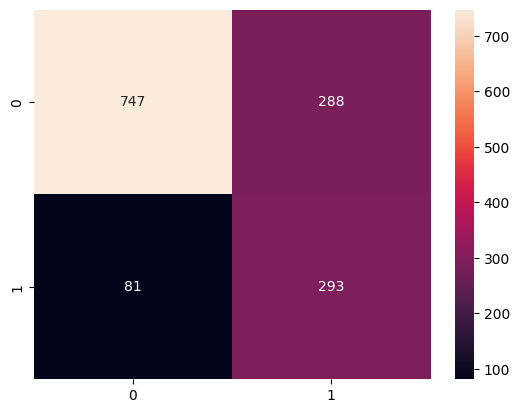

In [15]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

### Model Performance Summary

The logistic regression model was trained using balanced class weights to address class imbalance. The performance on the test set is as follows:

- **Accuracy:** 0.74  
- **Precision:** 0.50  
- **Recall:** 0.78  
- **F1 Score:** 0.61  

### Observations

- The model achieves a **high recall (0.78)**, meaning it successfully identifies most customers who are likely to churn.  
- Precision is moderate (0.50), indicating that some non-churning customers are incorrectly classified as churners.  
- This trade-off is acceptable in churn prediction, as failing to identify a churner (false negative) is more costly than incorrectly flagging a non-churner (false positive).  
- The model provides a strong baseline and demonstrates the effectiveness of logistic regression for this problem.